In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.naive_bayes import GaussianNB

In [35]:
# Load dataset only
path = '../data/cancer.csv'
df = pd.read_csv(path)


In [36]:
# Overview
print('Shape:', df.shape)
print('Value counts diagnosis:')
print(df['diagnosis'].value_counts())
display(df.head())


Shape: (569, 33)
Value counts diagnosis:
diagnosis
B    357
M    212
Name: count, dtype: int64


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [37]:
# Feature & target preparation
# Hapus kolom kosong jika ada (menghilangkan warning imputer)
if 'Unnamed: 32' in df.columns:
    df = df.drop(columns=['Unnamed: 32'])

y = (df['diagnosis'] == 'M').astype(int)
X = df.drop(columns=['id', 'diagnosis'])
print('Total fitur:', X.shape[1])


Total fitur: 30


In [38]:
# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Train:', X_train.shape, 'Test:', X_test.shape)


Train: (455, 30) Test: (114, 30)


In [39]:
# Train model & predict (handle NaNs in X by imputation)
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Model trained (NaNs imputed).')


Model trained (NaNs imputed).


In [40]:
# Accuracy & classification report
from sklearn.metrics import accuracy_score, classification_report
acc = accuracy_score(y_test, y_pred)
print('Akurasi:', round(acc,4))
print(classification_report(y_test, y_pred, digits=4))


Akurasi: 0.9386
              precision    recall  f1-score   support

           0     0.9114    1.0000    0.9536        72
           1     1.0000    0.8333    0.9091        42

    accuracy                         0.9386       114
   macro avg     0.9557    0.9167    0.9314       114
weighted avg     0.9440    0.9386    0.9372       114



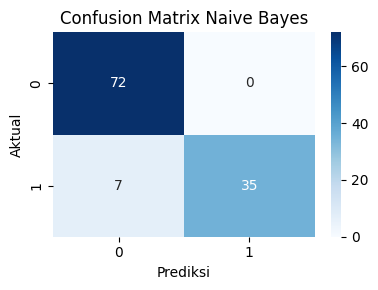

In [41]:
# Confusion matrix plot
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Naive Bayes')
plt.tight_layout()
plt.show()


In [42]:
# Prediction probabilities (first 10)
probs = model.predict_proba(X_test)[:10]
sample = pd.DataFrame({
    'y_true': y_test.iloc[:10].values,
    'y_pred': y_pred[:10],
    'prob_benign': np.round(probs[:,0],3),
    'prob_malignant': np.round(probs[:,1],3)
})
display(sample)


,y_true,y_pred,prob_benign,prob_malignant
0,0,0,1.000,0.000
1,1,1,0.000,1.000
2,0,0,0.984,0.016
3,1,0,0.997,0.003
4,0,0,1.000,0.000
5,0,0,0.990,0.010
6,1,0,0.735,0.265
7,0,0,1.000,0.000
8,0,0,1.000,0.000
9,0,0,1.000,0.000


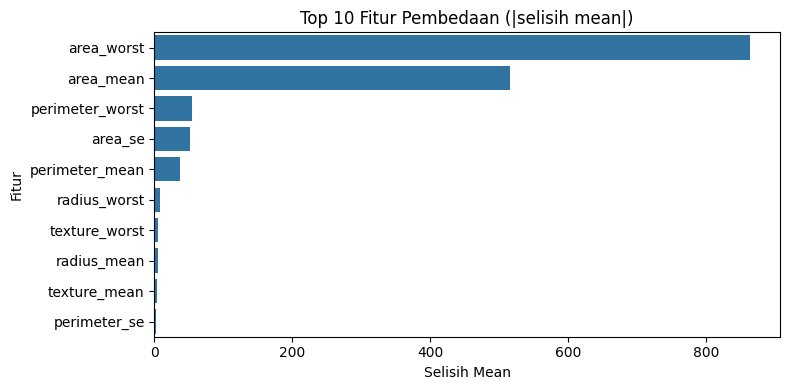

In [43]:
# Feature mean differences barplot (top 10)
means = pd.DataFrame({
    'benign_mean': X[y==0].mean(),
    'malignant_mean': X[y==1].mean()
})
diff = (means['malignant_mean'] - means['benign_mean']).abs().sort_values(ascending=False)
Top10 = diff.index[:10]
plt.figure(figsize=(8,4))
sns.barplot(x=diff.loc[Top10], y=Top10, orient='h')
plt.title('Top 10 Fitur Pembedaan (|selisih mean|)')
plt.xlabel('Selisih Mean')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()


In [44]:
# 5-Fold Cross Validation (Accuracy)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('nb', GaussianNB())
])
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')

print('Naive Bayes Cross Validation Accuracy (5-Fold):')
print('Scores:', cv_scores)
print('Mean Accuracy:', cv_scores.mean())
print('Std Deviation:', cv_scores.std())


Naive Bayes Cross Validation Accuracy (5-Fold):
Scores: [0.96491228 0.90350877 0.92982456 0.92982456 0.96460177]
Mean Accuracy: 0.9385343890700202
Std Deviation: 0.023468351296512962
